In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
STAT_PATH = "../experiments"
UNAVAILABILITY_NAME = os.path.join("exp", "unavailability")
EXP_NAME = "run"
BINS = 50


In [3]:
def read_unavailability_lengths(file_path):
    df = pd.read_csv(file_path, header=None, names=["unavailability_hours"])
    return df["unavailability_hours"].dropna()


def plot_density_histogram(ax, values, label, bins=BINS):
    ax.hist(values, bins=bins, density=True, histtype="step", linewidth=2, label=label)
    ax.set_title("Non-availability interval length density")
    ax.set_xlabel("Non-availability interval length, hours")
    ax.set_ylabel("Density")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)


def plot_empirical_cdf(ax, values, label):
    sorted_values = values.sort_values().reset_index(drop=True)
    cumulative_probability = (sorted_values.index + 1) / len(sorted_values)
    ax.plot(sorted_values, cumulative_probability, label=label)
    ax.set_title("Non-availability interval empirical CDF")
    ax.set_xlabel("Non-availability interval length, hours")
    ax.set_ylabel("Cumulative probability")
    ax.grid(True, which="both", linestyle="--", linewidth=0.5)


found ['run_0001', 'run_0002']


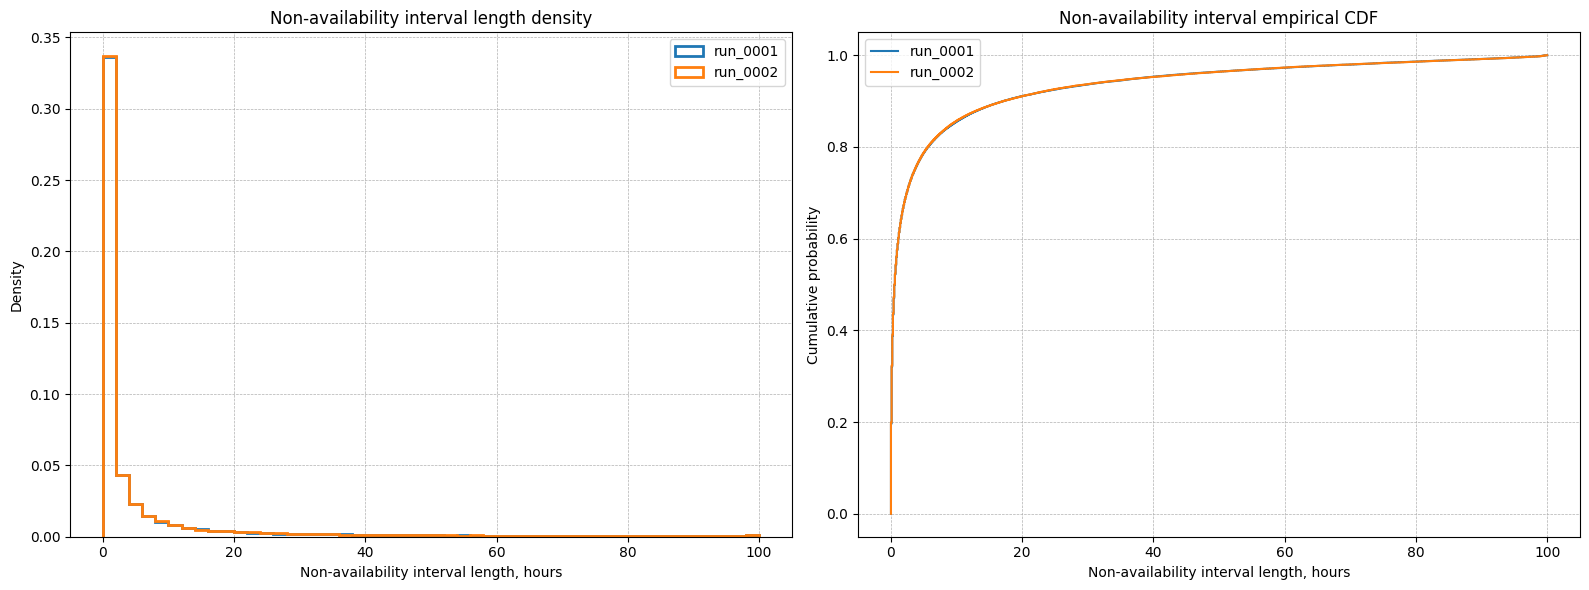

In [4]:
folders = sorted(
    f
    for f in os.listdir(STAT_PATH)
    if os.path.isdir(os.path.join(STAT_PATH, f)) and f.startswith(EXP_NAME)
)

if not folders:
    print(f"there is no folders in {STAT_PATH}")
else:
    print(f"found {folders}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for folder in folders:
    full_path = os.path.join(STAT_PATH, folder)
    unavailability_path = os.path.join(full_path, UNAVAILABILITY_NAME)

    if not os.path.exists(unavailability_path):
        print(f"skip {folder}: {UNAVAILABILITY_NAME} not found")
        continue

    values = read_unavailability_lengths(unavailability_path)
    if values.empty:
        print(f"skip {folder}: {UNAVAILABILITY_NAME} is empty")
        continue

    plot_density_histogram(axes[0], values, folder)
    plot_empirical_cdf(axes[1], values, folder)

axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()
